In [1]:
import pandas as pd
df =pd.read_csv("student_habits_performance.csv")

In [2]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set(style="whitegrid")

In [6]:
df.isna().sum().sum()

91

In [7]:
df.dropna(inplace=True)

In [8]:
df.duplicated().sum()

0

In [9]:
import warnings
warnings.filterwarnings("ignore")

In [10]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [11]:
df.describe(include="object").columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [12]:
categorical_cols = ["gender","part_time_job","diet_quality","parental_education_level","internet_quality","extracurricular_participation"]

In [13]:
for col in categorical_cols:
    print(f"value counts for {col}:\n {df[col].value_counts()}")

value counts for gender:
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
value counts for part_time_job:
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
value counts for diet_quality:
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
value counts for parental_education_level:
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
value counts for internet_quality:
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
value counts for extracurricular_participation:
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


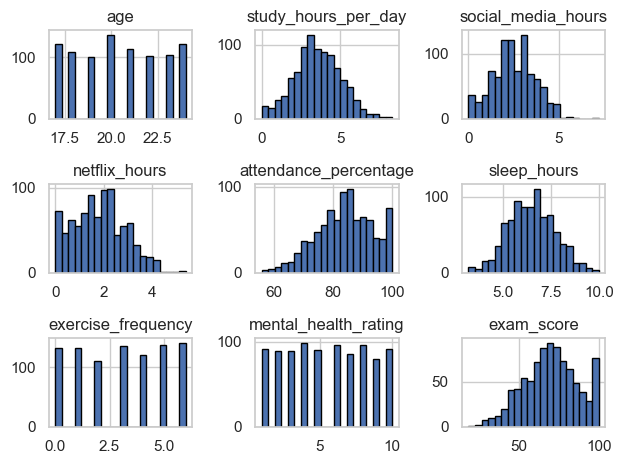

In [14]:
df.hist(bins=20,edgecolor="black")
plt.tight_layout()
plt.show()

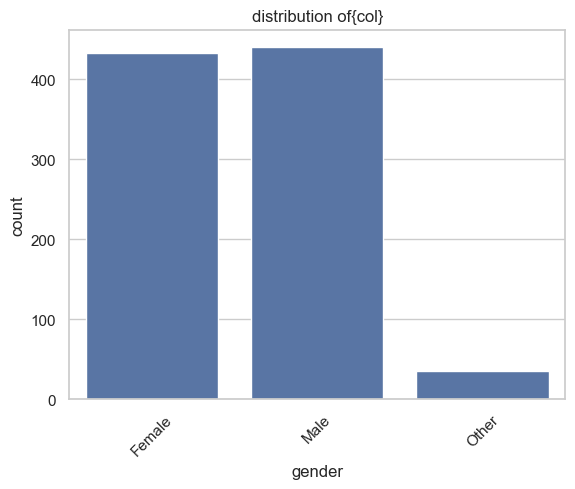

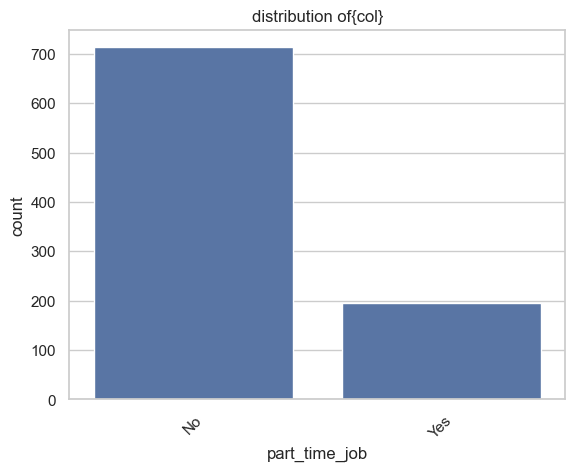

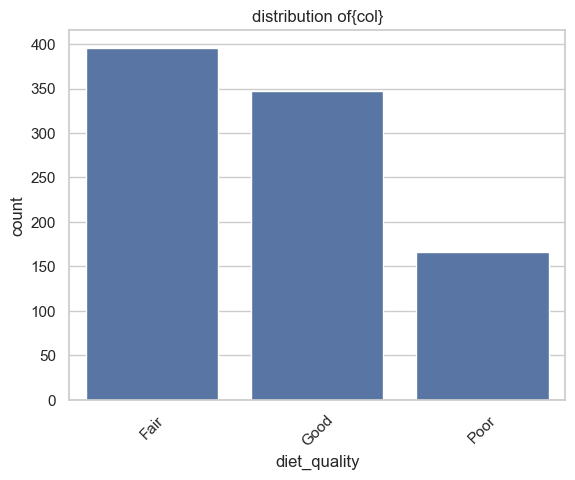

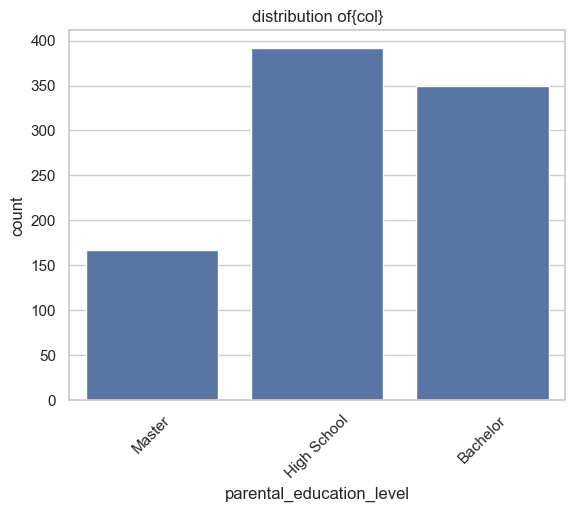

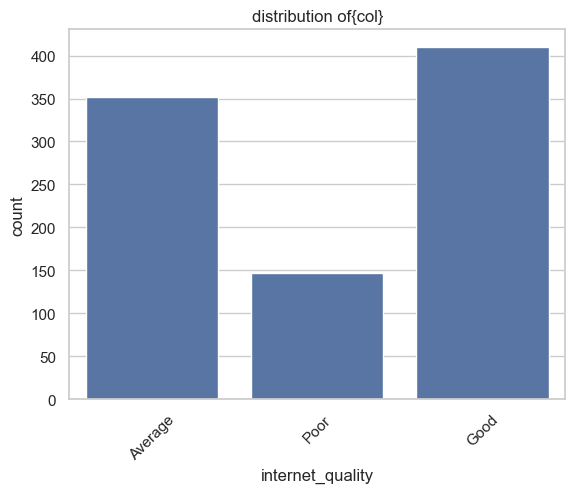

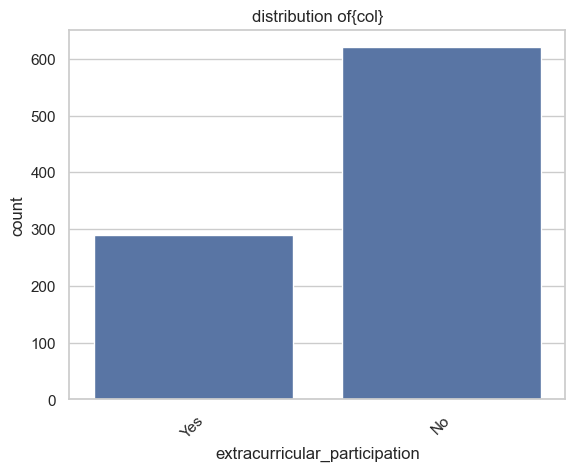

In [15]:
for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.title("distribution of{col}")
    plt.xticks(rotation=45)
    plt.show()

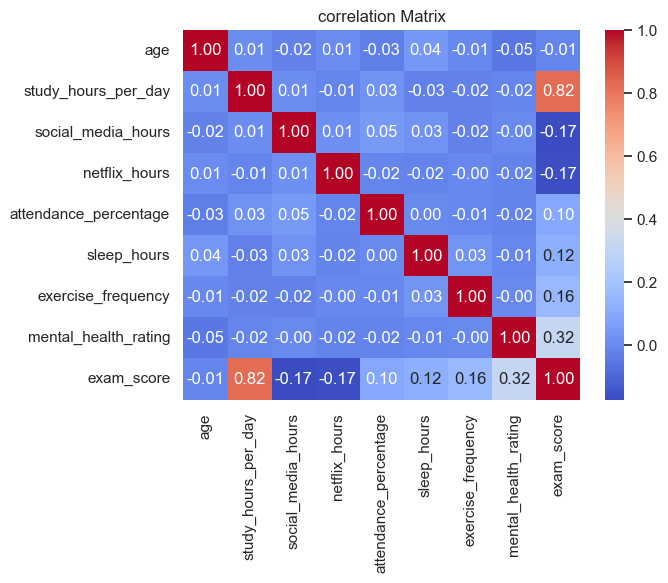

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap= "coolwarm",fmt=".2f")
plt.title("correlation Matrix")
plt.show()

In [17]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [18]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',    
       'mental_health_rating']

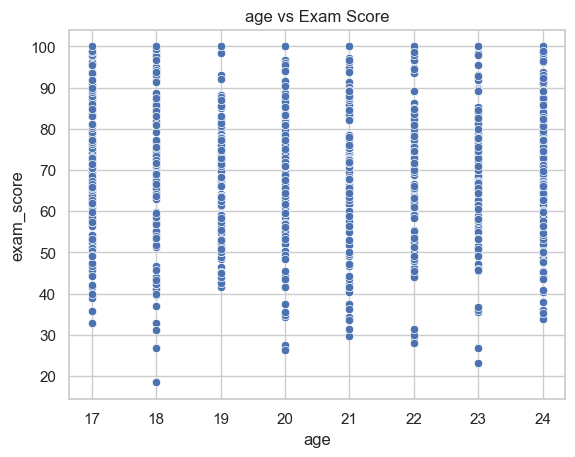

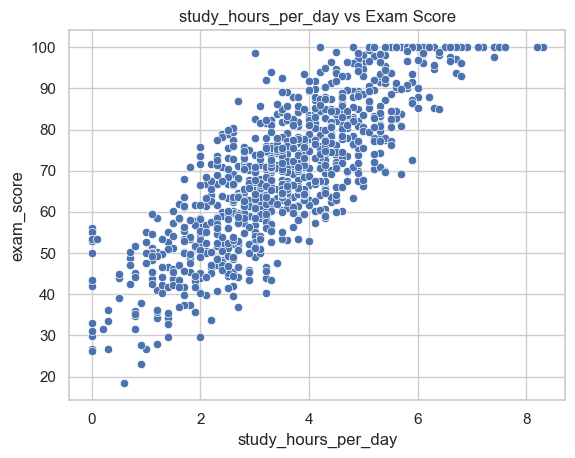

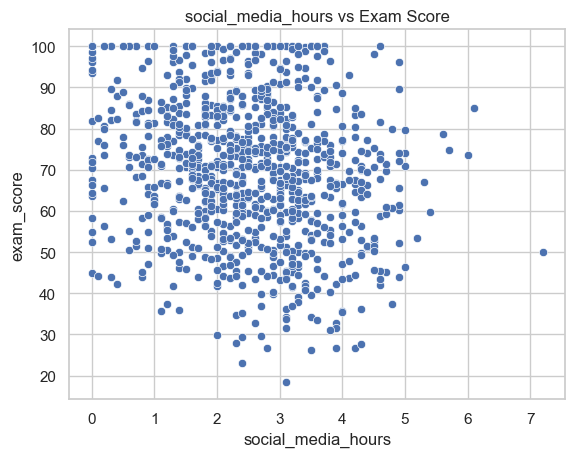

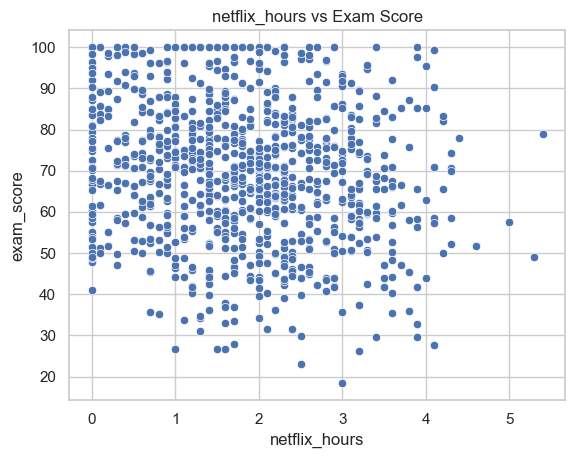

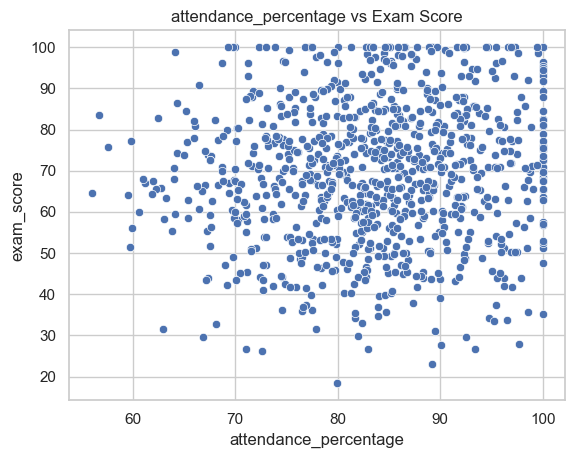

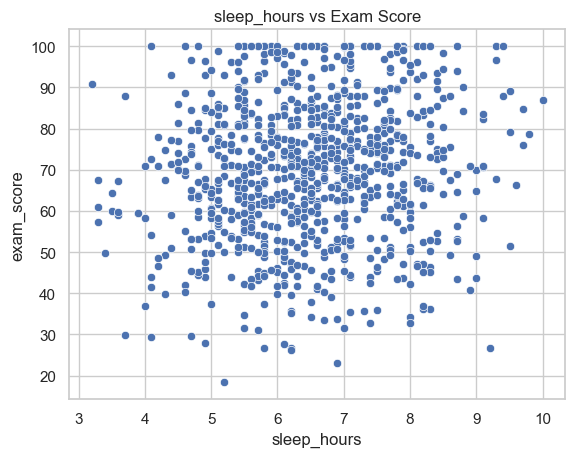

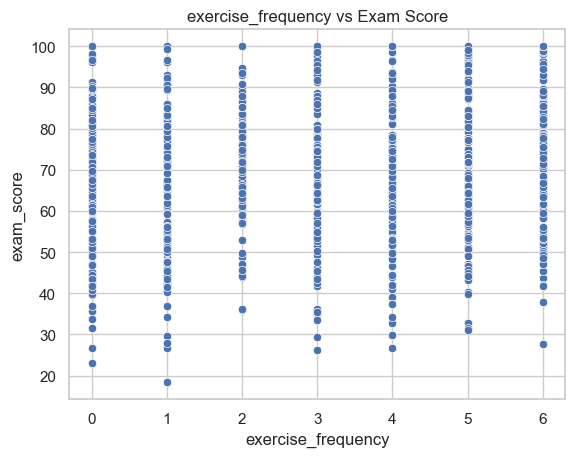

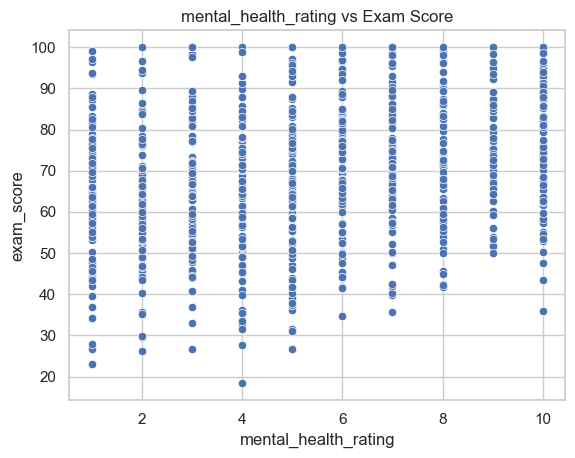

In [19]:
for feature in num_features:
    sns.scatterplot(data=df, x=feature, y="exam_score")
    plt.title(f"{feature} vs Exam Score")
    plt.show()

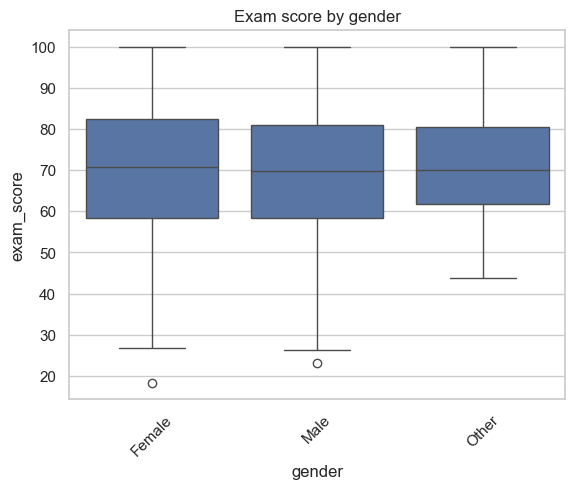

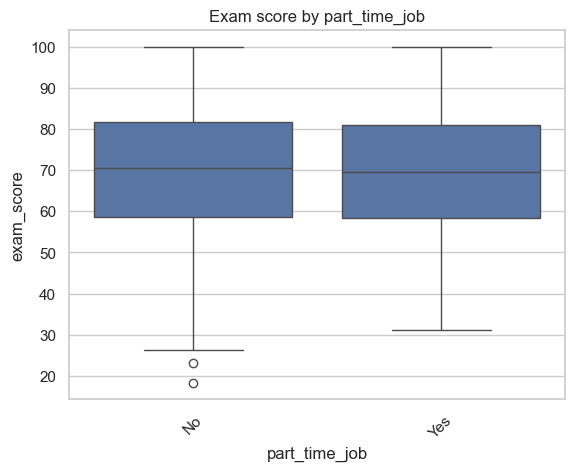

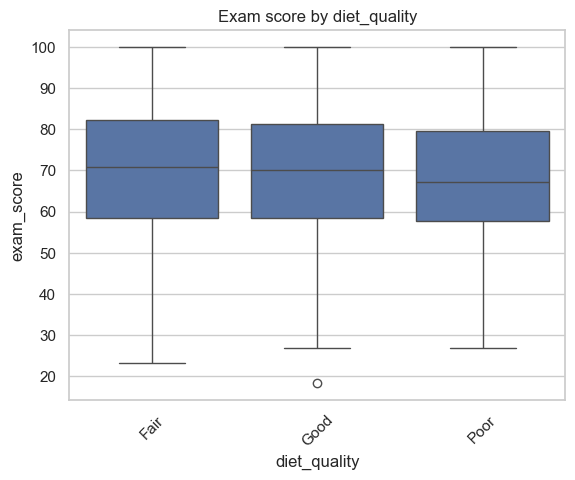

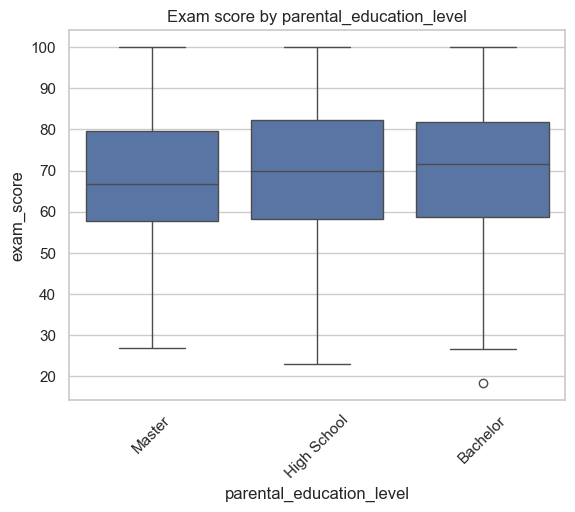

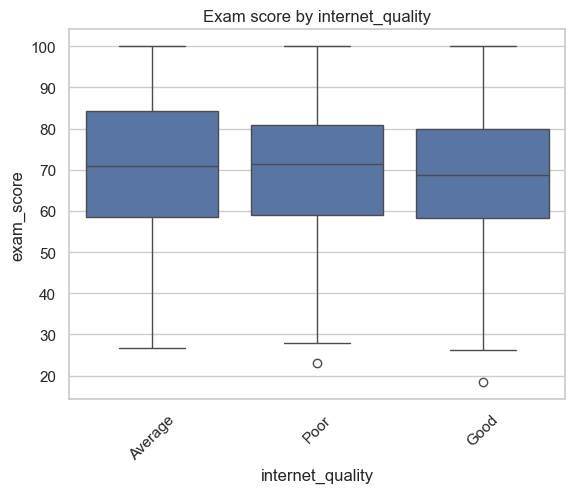

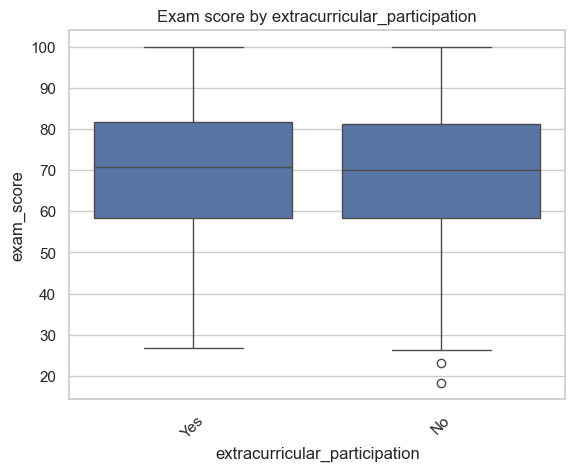

In [20]:
for col in categorical_cols:
    sns.boxplot(data=df, x=col, y="exam_score")
    plt.title(f"Exam score by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [22]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [23]:
df.head(2)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0


In [24]:
feature = ["study_hours_per_day","attendance_percentage","sleep_hours","mental_health_rating","part_time_job"]

In [25]:
target = "exam_score"

In [26]:
df_model = df[feature + [target]].copy() 

In [27]:
df_model

,study_hours_per_day,attendance_percentage,sleep_hours,mental_health_rating,part_time_job,exam_score
0,0.0,85.0,8.0,8,No,56.2
1,6.9,97.3,4.6,8,No,100.0
2,1.4,94.8,8.0,1,No,34.3
3,1.0,71.0,9.2,1,No,26.8
4,5.0,90.9,4.9,1,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,7.5,6,No,76.1
996,2.9,86.0,6.8,6,Yes,65.9
997,3.0,61.9,6.5,9,No,64.4
998,5.4,100.0,7.6,1,Yes,69.7


In [28]:
le = LabelEncoder()

In [29]:
df_model["part_time_job"] = le.fit_transform(df_model["part_time_job"])

In [30]:
df_model

,study_hours_per_day,attendance_percentage,sleep_hours,mental_health_rating,part_time_job,exam_score
0,0.0,85.0,8.0,8,0,56.2
1,6.9,97.3,4.6,8,0,100.0
2,1.4,94.8,8.0,1,0,34.3
3,1.0,71.0,9.2,1,0,26.8
4,5.0,90.9,4.9,1,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,7.5,6,0,76.1
996,2.9,86.0,6.8,6,1,65.9
997,3.0,61.9,6.5,9,0,64.4
998,5.4,100.0,7.6,1,1,69.7


In [31]:
X = df_model[feature]

In [32]:
y = df_model[target]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [34]:
len (y_test)

182

In [35]:
len (y_train)

727

In [36]:
models = {
    "LinearRegression":{
        "model":LinearRegression(),
        "params":{}
    },
    "DecisionTree":{ 
    "model":DecisionTreeRegressor(),
    "params": {"max_depth":[3,5,10], "min_samples_split":[2,5]}
    },
    "RandomForest":{
    "model": RandomForestRegressor(),
    "params":{"n_estimators":[50,100], "max_depth":[5,10]}
    }
}

In [37]:
best_models = []

In [40]:
for name, config in models.items():
    print (f"Training{name}")

    grid =  GridSearchCV(config["model"],config["params"],cv=5, scoring="neg_mean_squared_error")
    grid.fit(X_train,y_train)

    y_pred = grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2= r2_score(y_test, y_pred)

    best_models.append({
        "model":name,
        "best_params": grid.best_params_,
        "rmse": rmse,
        "r2":r2
    })

TrainingLinearRegression
TrainingDecisionTree
TrainingRandomForest


In [42]:
best_models

[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': 7.127610436101088,
  'r2': 0.7978012249376885},
 {'model': 'DecisionTree',
  'best_params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': 8.716641074791339,
  'r2': 0.6975950212921117},
 {'model': 'RandomForest',
  'best_params': {'max_depth': 10, 'n_estimators': 100},
  'rmse': 7.49945114700637,
  'r2': 0.7761538800348993}]

In [43]:
result_df = pd.DataFrame(best_models)

In [45]:
result_df.sort_values(by="rmse")

,model,best_params,rmse,r2
0,LinearRegression,{},7.127610,0.797801
2,RandomForest,"{'max_depth': 10, 'n_estimators': 100}",7.499451,0.776154
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.716641,0.697595


In [46]:
import joblib

best_row= result_df.sort_values(by="rmse").iloc[0]

In [47]:
best_row

model          LinearRegression
best_params                  {}
rmse                    7.12761
r2                     0.797801
Name: 0, dtype: object

In [48]:
best_model_name = best_row["model"]

In [49]:
best_model_name

'LinearRegression'

In [51]:
best_model_config = models[best_model_name]

In [52]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [53]:
final_model = best_model_config["model"]

In [54]:
final_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
final_model.predict(X_test)

In [57]:
joblib.dump(final_model,"best_model.pkl")

['best_model.pkl']

In [58]:
joblib.load("best_model.pkl").predict(X_test)

array([ 80.07572706,  93.42130856,  46.89711801,  48.01856192,
        66.5958151 ,  85.7737938 ,  75.7404905 ,  80.37605908,
        68.45406642,  59.74918922,  55.78485738,  68.64068393,
        69.35389946,  65.13307337,  71.9069882 ,  78.71971636,
        76.55263164,  86.1259658 ,  63.04843369,  84.75734186,
        59.41323383,  43.14340981,  63.09137222,  76.0390916 ,
        74.83885426,  44.07751614,  79.09422925,  71.00086671,
        48.86907863,  73.79670885,  39.63541895,  54.20184513,
        66.72764266,  66.55221819,  56.52867139,  54.26161987,
        49.28725829,  52.04571946,  54.55013746,  62.92406585,
        69.44137515,  67.31865096,  80.46594508,  86.41513985,
        64.21237739,  70.71345219,  77.30359466,  68.66172969,
        80.39472169,  58.73592725,  47.5688949 ,  66.31366546,
        56.51857377,  78.14942594,  86.04857975,  64.97418345,
        43.50243593,  64.81476205,  62.03082708,  81.60879862,
        54.97205488, 101.01138266,  84.45415703,  65.73